In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
dataset=pd.read_csv('C:\\Users\\sowja\\OneDrive\\Desktop\\practice_projects\\50_Startups.csv')
x=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[("encoder", OneHotEncoder(drop='first'), [3])],remainder="passthrough")
x = ct.fit_transform(x)

In [28]:
feature_names = ct.get_feature_names_out()
print(feature_names)

['encoder__x3_Florida' 'encoder__x3_New York' 'remainder__x0'
 'remainder__x1' 'remainder__x2']


In [29]:
print(regression.coef_)

[ 4.58070775e+02 -1.23515673e+03  8.04937292e-01 -9.12577104e-02
  2.80672826e-02]


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=42)

In [20]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression()
regression.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
pd.DataFrame(x_train).head()

,0,1,2,3,4
0,0.0,0.0,134615.46,147198.87,127716.82
1,1.0,0.0,27892.92,84710.77,164470.71
2,1.0,0.0,1315.46,115816.21,297114.46
3,0.0,0.0,0.0,135426.92,0.0
4,0.0,1.0,114523.61,122616.84,261776.23


In [22]:
x_test.shape

(15, 5)

In [23]:
y_pred= regression.predict(x_test)


In [24]:
print(len(y_test))
print(len(y_pred))

15
15


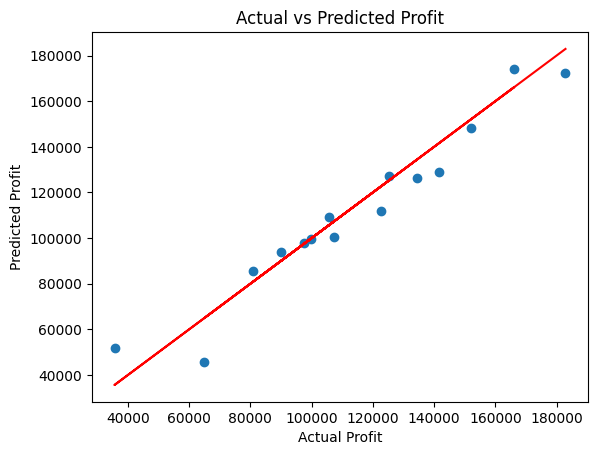

In [25]:

plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='red')
plt.title("Actual vs Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.show()

In [27]:
print("Intercept:", regression.intercept_)
print("Coefficients:", regression.coef_)

Intercept: 57412.64071481361
Coefficients: [ 4.58070775e+02 -1.23515673e+03  8.04937292e-01 -9.12577104e-02
  2.80672826e-02]


In [26]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9397108063355469


In [ ]:
#residuals = y_test - y_pred

#plt.scatter(y_pred, residuals)
#plt.axhline(y=0, color='red')
#plt.xlabel("Predicted")
#plt.ylabel("Residuals")
#plt.show()